In [353]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [354]:
dataset=pd.read_csv(r"C:\Users\MRINALIN PANIGRAHI\OneDrive\ROHNIT coding\data science\dataset\diabetes.csv")
print("Data shape -",dataset.shape)
dataset.head(5)

Data shape - (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [355]:
dataset.info()
dataset.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [356]:
print("Duplicate value(Rows) :",dataset.duplicated().sum())

Duplicate value(Rows) : 0


In [357]:
print("NULL VALUES IN DATA SET IN PARTICULAR COLUMNS :-\n")
print(dataset.isnull().sum())

NULL VALUES IN DATA SET IN PARTICULAR COLUMNS :-

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [358]:
columns = ["Pregnancies","Glucose",
        "BloodPressure","SkinThickness",
        "Insulin","BMI",
        "DiabetesPedigreeFunction","Age",
    ]
print("Number and percentage of values which are not null but are valued as zero :- \n")
for i in columns:
    count_zeros = (dataset[i]== 0).sum()
    percentage=count_zeros /len(dataset)*100
    print(f"{i:^25s}:{count_zeros:^4d} ({percentage:^.2f}%)")

Number and percentage of values which are not null but are valued as zero :- 

       Pregnancies       :111  (14.45%)
         Glucose         : 5   (0.65%)
      BloodPressure      : 35  (4.56%)
      SkinThickness      :227  (29.56%)
         Insulin         :374  (48.70%)
           BMI           : 11  (1.43%)
DiabetesPedigreeFunction : 0   (0.00%)
           Age           : 0   (0.00%)


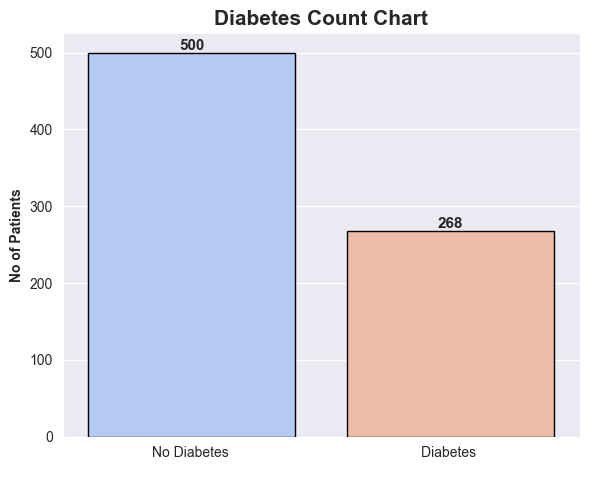

In [359]:

plt.figure(figsize=(6,5))
sns.set_style("darkgrid")

graph = sns.countplot(x="Outcome",data=dataset,
    legend=False, hue="Outcome",
    palette="coolwarm",edgecolor="black"
)

graph.set_xticks([0,1])
graph.set_xticklabels(["No Diabetes ", "Diabetes "])

for i in graph.patches:
    graph.annotate(
        text=f"{int(i.get_height())}",
        xy=[i.get_x() + i.get_width()/2, i.get_height()],
        ha="center",va="bottom",
        fontsize=11,
        fontweight="heavy"
    )

graph.set_title("Diabetes Count Chart",fontsize=15,fontweight="heavy")
graph.set_xlabel(" ")
graph.set_ylabel("No of Patients",fontsize=10,fontweight="heavy")
plt.tight_layout()

plt.show()

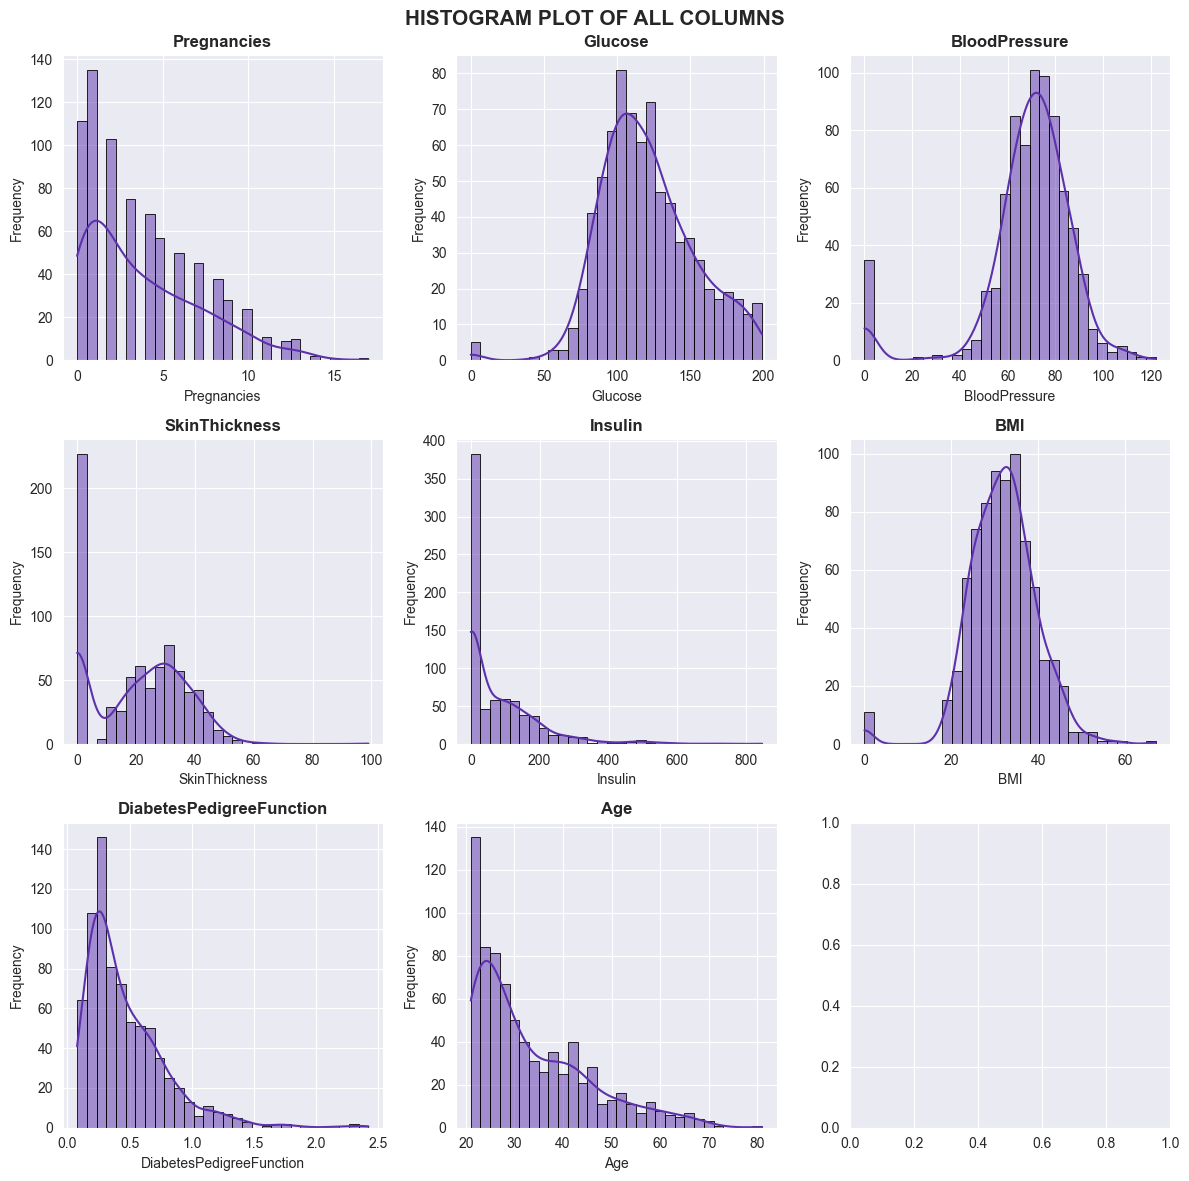

In [360]:
fig,sub_plotno=plt.subplots(3,3,figsize=(12,12))
sub_plotno = sub_plotno.flatten()
for i,j in enumerate(dataset.columns[:-1]):
    sns.histplot(dataset[j],ax=sub_plotno[i],kde=True,
                color="#5C31AB",bins=30,edgecolor='black')
    
    sub_plotno[i].set_title(j,fontweight='bold')
    sub_plotno[i].set_ylabel("Frequency")

plt.suptitle("HISTOGRAM PLOT OF ALL COLUMNS",fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

data preprocessing

In [361]:
dataset_clean = dataset.copy()
setcol =["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for i in setcol:
    median_value = dataset_clean[dataset_clean[i]!=0][i].median()
    dataset_clean[i] = dataset_clean[i].replace(0,median_value)
    print(f"Replaced 0s in {i} with median= {median_value:.2f}")

print("\n")
print("Zero counts after processing:")
for i in setcol:
    print(f"{i}:{(dataset_clean[i]==0).sum()}")

Replaced 0s in Glucose with median= 117.00
Replaced 0s in BloodPressure with median= 72.00
Replaced 0s in SkinThickness with median= 29.00
Replaced 0s in Insulin with median= 125.00
Replaced 0s in BMI with median= 32.30


Zero counts after processing:
Glucose:0
BloodPressure:0
SkinThickness:0
Insulin:0
BMI:0


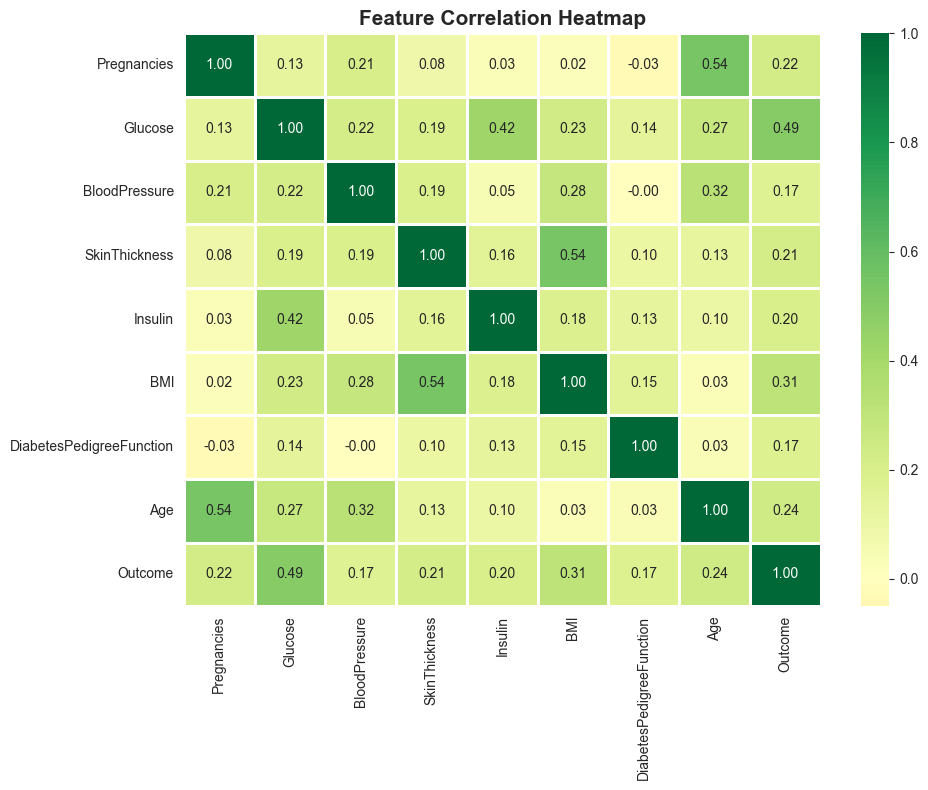

In [362]:

fig = plt.figure(figsize=(10,8))

sns.heatmap(
    dataset_clean.corr(),vmax=1.0,vmin=-0.05,
    annot=True,fmt=".2f",
    cmap="RdYlGn",center=0,
    linewidths=1,annot_kws={"size":10},
)

plt.title("Feature Correlation Heatmap",fontsize=15,fontweight="bold")

plt.tight_layout()
plt.show()

In [363]:
corr = dataset_clean.corr()["Outcome"].sort_values(ascending=False)
print(corr)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


C:\Users\MRINALIN PANIGRAHI\AppData\Local\Temp\ipykernel_24384\3246990220.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diabetes","Diabetes"])
C:\Users\MRINALIN PANIGRAHI\AppData\Local\Temp\ipykernel_24384\3246990220.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diabetes","Diabetes"])
C:\Users\MRINALIN PANIGRAHI\AppData\Local\Temp\ipykernel_24384\3246990220.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diabetes","Diabetes"])


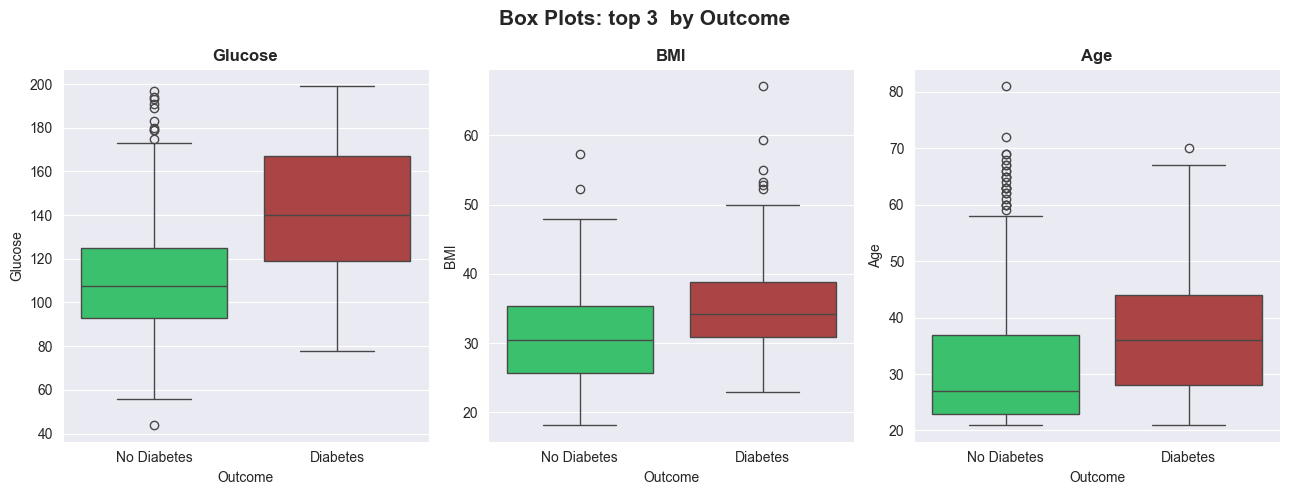

In [364]:
top3 = ["Glucose","BMI","Age"]
fig,axes=plt.subplots(1,3,figsize=(13,5))
for i,j in enumerate(top3):
    sns.boxplot(
        x="Outcome",y=j,
        data=dataset_clean,
        hue="Outcome",legend=False,
        palette=["#25D767", "#BC3333"],
        ax=axes[i],order=[0,1]
    )
    axes[i].set_xticklabels(["No Diabetes","Diabetes"])
    axes[i].set_title(j,fontweight="bold")
plt.suptitle("Box Plots: top 3  by Outcome",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.show()

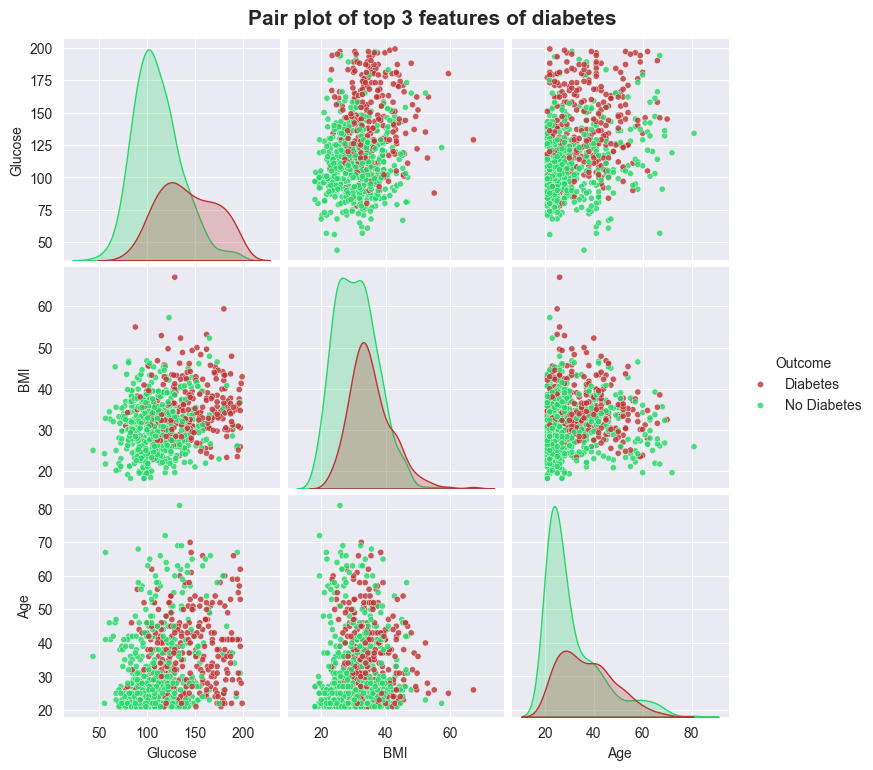

In [365]:
pair_df = dataset_clean[top3 + ["Outcome"]].copy()
pair_df['Outcome'] = pair_df['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})

pairgraph = sns.pairplot(
    pair_df, hue='Outcome',
    palette={'No Diabetes':"#25D767",'Diabetes':"#BC3333"},
    diag_kind='kde',
    plot_kws={'alpha': 0.8, 's': 20}
)
pairgraph.fig.suptitle("Pair plot of top 3 features of diabetes",y=1.02,fontsize=15,fontweight='bold')
plt.show()

In [366]:
top3 = ["Glucose","BMI","Age"]
X = dataset_clean[top3].values
Y=dataset_clean["Outcome"].values
X_mean=X.mean(axis=0)
X_std=X.std(axis=0)
X_normal=(X - X_mean)/X_std
X_normal


array([[ 0.86604475,  0.16661938,  1.4259954 ],
       [-1.20506583, -0.85219976, -0.19067191],
       [ 2.01666174, -1.33250021, -0.10558415],
       ...,
       [-0.02157407, -0.910418  , -0.27575966],
       [ 0.14279979, -0.34279019,  1.17073215],
       [-0.94206766, -0.29912651, -0.87137393]], shape=(768, 3))

In [367]:
np.random.seed(42)
index=np.random.permutation(len(dataset_clean))
split=int(0.78125*len(dataset_clean))
train_idx=index[:split]
test_idx=index[split:]
X_train=X_normal[train_idx]
y_train=Y[train_idx]
X_test=X_normal[test_idx]
y_test=Y[test_idx]

X_train_2=np.hstack([np.ones((len(X_train),1)),X_train])
X_test_2=np.hstack([np.ones((len(X_test),1)),X_test])
print(f'Training size: {len(X_train)}, Test size: {len(X_test)}')

Training size: 600, Test size: 168


In [368]:
X.T

array([[148. ,  85. , 183. , ..., 121. , 126. ,  93. ],
       [ 33.6,  26.6,  23.3, ...,  26.2,  30.1,  30.4],
       [ 50. ,  31. ,  32. , ...,  30. ,  47. ,  23. ]], shape=(3, 768))

In [369]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def binary_cross_entropy(X, y, weights):
    p=sigmoid(X@weights)
    return -np.mean(y*np.log(p+1e-9)+(1-y)*np.log(1-p+1e-9))

def fit_logistic(X, y,learnrate,trainingrounds):
    weights=np.zeros(X.shape[1])
    losses, traininglist=[],[]
    for ep in range(trainingrounds):
        p  = sigmoid(X@weights)
        weights -= learnrate*(X.T @ (p - y))/len(y)
        if ep % 50 == 0:
            losses.append(binary_cross_entropy(X,y,weights))
            traininglist.append(ep)
    return weights,losses,traininglist

weights,losses,traininglist = fit_logistic(X_train_2,y_train,learnrate=0.01,trainingrounds=2000)

print('Learned weights:')
for name, val in zip(['Bias', 'Glucose', 'BMI', 'Age'], weights):
    print(f'  {name:10s}: {val:.4f}')
# print(X_train_2,"\n",y_train)

Learned weights:
  Bias      : -0.7846
  Glucose   : 1.0233
  BMI       : 0.5332
  Age       : 0.3209


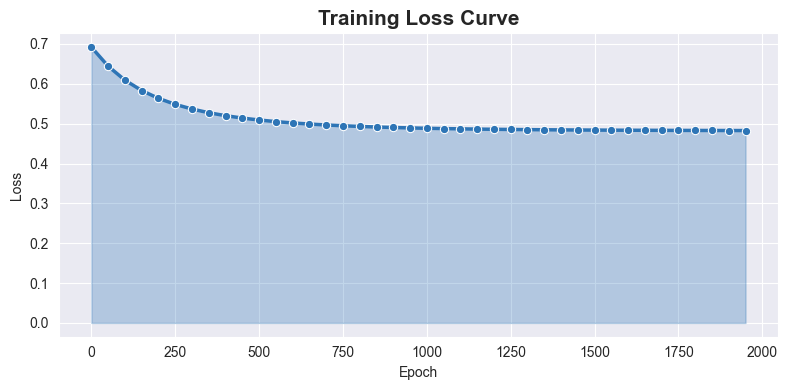

In [384]:
loss_df = pd.DataFrame({'Epoch': traininglist, 'Loss': losses})

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=loss_df, x='Epoch', y='Loss',
            marker='o', color='#2E75B6', linewidth=2.5, ax=ax)
ax.fill_between(loss_df['Epoch'], loss_df['Loss'], alpha=0.28, color="#226DB4")
ax.set_title('Training Loss Curve',fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

In [371]:
y_prob = sigmoid(X_test_2 @ weights)
y_pred = (y_prob >= 0.5).astype(int)

tp = np.sum((y_pred==1) & (y_test==1))
tn = np.sum((y_pred==0) & (y_test==0))
fp = np.sum((y_pred==1) & (y_test==0))
fn = np.sum((y_pred==0) & (y_test==1))

accuracy  = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0

print(f'Accuracy : {accuracy:.4f}  ({accuracy:.2%})')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'\nTP={tp}  TN={tn}  FP={fp}  FN={fn}')

Accuracy : 0.7560  (75.60%)
Precision: 0.7021
Recall   : 0.5500
F1 Score : 0.6168

TP=33  TN=94  FP=14  FN=27


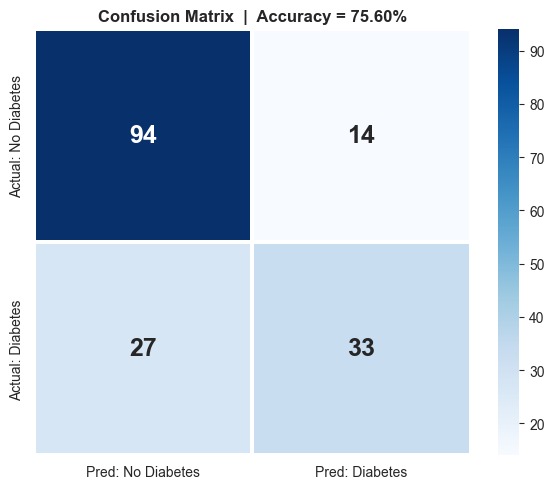

In [ ]:
cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Pred: No Diabetes', 'Pred: Diabetes'],
    yticklabels=['Actual: No Diabetes', 'Actual: Diabetes'],
    linewidths=1.5, linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold'}
)
ax.set_title(f'Confusion Matrix  |  Accuracy = {accuracy:.2%}',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\MRINALIN PANIGRAHI\AppData\Local\Temp\ipykernel_24384\1397377636.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df,


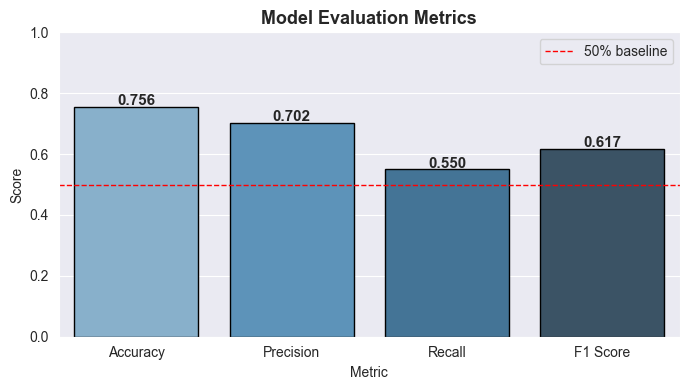

In [ ]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score':  [accuracy, precision, recall, f1]
})
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x='Metric', y='Score', data=metrics_df,
            palette='Blues_d',edgecolor='black', ax=ax)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.005),
                ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% baseline')
ax.legend()
ax.set_title('Model Evaluation Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()